# Econ 148 Project 3: The Fake News Effect (Thaler) Reproduction

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount = True)

Mounted at /content/drive


### Install Required Libraries

This cell installs the `linearmodels` and `pyfixest` libraries, which are not installed by default (can't import them w/o this first)

In [ ]:
!pip install linearmodels
!pip install pyfixest

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.3/72.3 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 48.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.1/51.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 607.2/607.2 kB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 70.0 MB/s eta 0:00:00


### Import Necessary Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

from linearmodels.panel import PanelOLS
import warnings
import pyfixest as pf
import matplotlib.patches as mpatches
from IPython.display import display


from linearmodels import AbsorbingLS

### Load the Dataset

This cell loads the original `cleaned_data.csv` file into a pandas DataFrame named `df` and displays the first 5 rows

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Econ148_project_data/cleaned_data.csv')
df.head(5)

,id_in_session,code,index_in_pages,current_page_name,time_started,payoff,consent,treatment,age_temp,gender,...,mean_prob_rep_temp,mean_prob_rep,mean_prob_dem_temp,mean_prob_dem,mean_prob_net,mean_prob_net_mean,mean_prob_net_sd,mean_prob_net_z,out_of_range_q,out_of_range
0,213,00d576h7,155,Results,2018-06-25 20:15:41.255206+00:00,0,NaN,SND,NaN,NaN,...,NaN,0.516667,NaN,0.7,-0.183333,-0.06448,0.184348,-0.644722,0,0
1,213,00d576h7,155,Results,2018-06-25 20:15:41.255206+00:00,0,NaN,SND,NaN,NaN,...,NaN,0.516667,NaN,0.7,-0.183333,-0.06448,0.184348,-0.644722,0,0
2,213,00d576h7,155,Results,2018-06-25 20:15:41.255206+00:00,0,NaN,SND,NaN,NaN,...,NaN,0.516667,0.7,0.7,-0.183333,-0.06448,0.184348,-0.644722,0,0
3,213,00d576h7,155,Results,2018-06-25 20:15:41.255206+00:00,0,NaN,SND,NaN,NaN,...,0.516667,0.516667,NaN,0.7,-0.183333,-0.06448,0.184348,-0.644722,0,0
4,213,00d576h7,155,Results,2018-06-25 20:15:41.255206+00:00,0,NaN,SND,NaN,NaN,...,NaN,0.516667,NaN,0.7,-0.183333,-0.06448,0.184348,-0.644722,0,0


# Replicate Table 1

Manual entry of topics and their left vs right wing interpretations to replicate Table 1 from the Thaler

In [ ]:
data = {
    "Topic": [
        "US crime",
        "Upward mobility",
        "Racial discrimination",
        "Gender",
        "Refugees",
        "Climate change",
        "Gun reform",
        "Media bias",
        "Party performance",
        "Own performance"
    ],
    "Pro-Democrat motives": [
        "Got better under Obama",
        "Low in US after tax cuts",
        "Severe in labor market",
        "Girls better at math",
        "Decreased violent crime",
        "Scientific consensus",
        "Decreased homicides",
        "Media not mostly Dems",
        "Higher for Dems over Reps",
        "Higher for self over others"
    ],
    "Pro-Republican motives": [
        "Got worse under Obama",
        "High in US after tax cuts",
        "Not severe in labor market",
        "Boys better at math",
        "Increased violent crime",
        "No scientific consensus",
        "Didn’t decrease homicides",
        "Media mostly Dems",
        "Higher for Reps over Dems",
        "Higher for self over others"
    ]
}

t1_df = pd.DataFrame(data)

t1_df

,Topic,Pro-Democrat motives,Pro-Republican motives
0,US crime,Got better under Obama,Got worse under Obama
1,Upward mobility,Low in US after tax cuts,High in US after tax cuts
2,Racial discrimination,Severe in labor market,Not severe in labor market
3,Gender,Girls better at math,Boys better at math
4,Refugees,Decreased violent crime,Increased violent crime
5,Climate change,Scientific consensus,No scientific consensus
6,Gun reform,Decreased homicides,Didn’t decrease homicides
7,Media bias,Media not mostly Dems,Media mostly Dems
8,Party performance,Higher for Dems over Reps,Higher for Reps over Dems
9,Own performance,Higher for self over others,Higher for self over others


### Replicate Figure 1: CDF of Assessments of Pro-Party and Anti-Party News

This cell filters data for politicized news (pro-party or anti-party) and generates an Empirical Cumulative Distribution Function (ECDF) plot. This plot visualizes the distribution of perceived truthfulness (`prob_true`) for both pro-party and anti-party news, allowing for a comparison of how these two types of news are assessed.

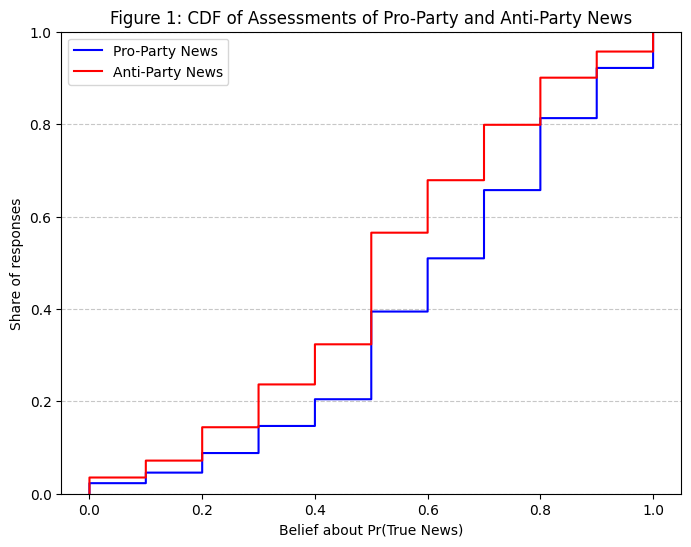

In [ ]:
# Filter for politicized news where it is either pro-party or anti-party
fig1_data = df[(df['politicized_news'] == 1) &
               ((df['pro_party'] == 1) | (df['anti_party'] == 1))].copy()

plt.figure(figsize=(8, 6), facecolor='white')

# Pro-Party CDF
sns.ecdfplot(data=fig1_data[fig1_data['pro_party'] == 1], x='prob_true',
             label='Pro-Party News', color='blue')

# Anti-Party CDF
sns.ecdfplot(data=fig1_data[fig1_data['anti_party'] == 1], x='prob_true',
             label='Anti-Party News', color='red')

plt.title("Figure 1: CDF of Assessments of Pro-Party and Anti-Party News")
plt.xlabel("Belief about Pr(True News)")
plt.ylabel("Share of responses")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Replicate Figure 2: Politically Motivated Reasoning

This cell prepares data and generates a bar chart (Figure 2) illustrating politically motivated reasoning based on news direction and partisanship, showing mean demeaned `prob_true` and 95% confidence intervals across different groups.

In [ ]:
# Filter data for those with a party preference and receiving messages
fig2_data = df[(df['net_party'] != 0) &
               ((df['pro_party'] == 1) | (df['neutral_news'] == 1) | (df['anti_party'] == 1)) &
               ((df['message_greater'] == 1) | (df['message_less'] == 1))].copy()

# Assigns alignment and partisanship scale 1-5
def get_party_group(row):
    if row['anti_party'] == 1 and row['partisan'] == 1: return 1
    if row['anti_party'] == 1 and row['moderate'] == 1: return 2
    if row['neutral_news'] == 1: return 3
    if row['pro_party'] == 1 and row['moderate'] == 1: return 4
    if row['pro_party'] == 1 and row['partisan'] == 1: return 5
    return None

fig2_data['party_group'] = fig2_data.apply(get_party_group, axis=1)
fig2_data = fig2_data.dropna(subset=['party_group'])

# Calculate mean, SD, and 95% Confidence Intervals
stats_df = fig2_data.groupby('party_group')['prob_true_demeaned'].agg(['mean', 'std', 'count']).reset_index()

# Calculate 95% CI using t-distribution: mean +/- t * (std / sqrt(n))
t_val = stats.t.ppf(1 - 0.025, stats_df['count'] - 1)
stats_df['ci_yerr'] = t_val * (stats_df['std'] / np.sqrt(stats_df['count']))


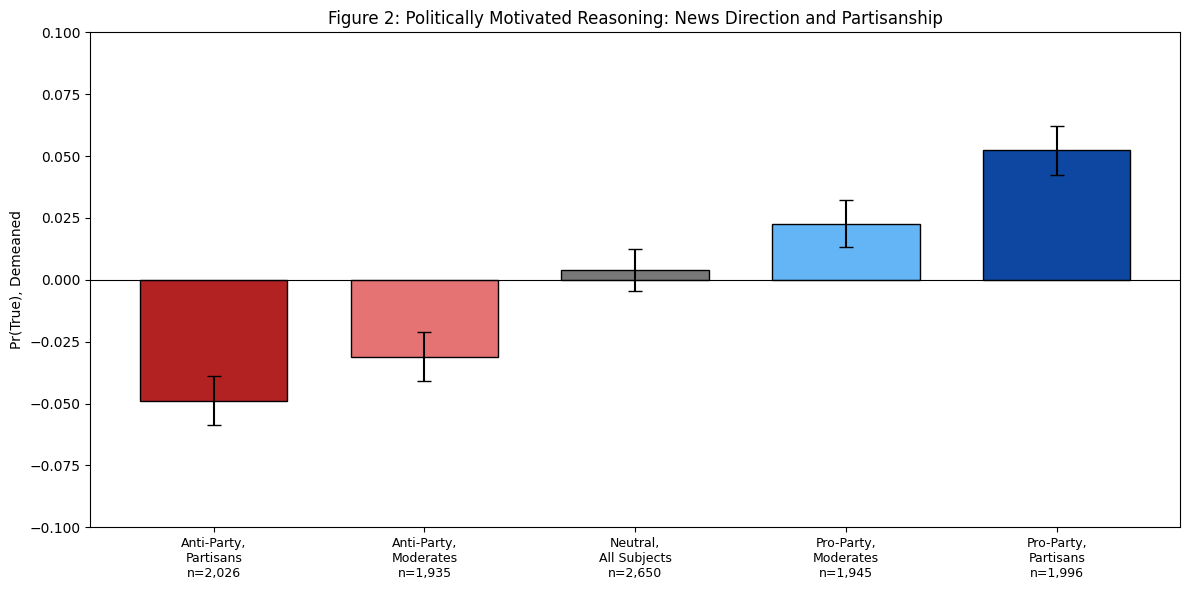

In [ ]:
# Plotting - claude help here
labels = [
    "Anti-Party,\nPartisans\nn=2,026",
    "Anti-Party,\nModerates\nn=1,935",
    "Neutral,\nAll Subjects\nn=2,650",
    "Pro-Party,\nModerates\nn=1,945",
    "Pro-Party,\nPartisans\nn=1,996"
]
colors = ['#B22222', '#E57373', '#787878', '#64B5F6', '#0D47A1']

plt.figure(figsize=(12, 6), facecolor='white')
bars = plt.bar(stats_df['party_group'], stats_df['mean'], yerr=stats_df['ci_yerr'],
               capsize=5, color=colors, edgecolor='black', width=0.7)

plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(stats_df['party_group'], labels, fontsize=9)
plt.ylim(-0.1, 0.1)
plt.ylabel("Pr(True), Demeaned")
plt.title("Figure 2: Politically Motivated Reasoning: News Direction and Partisanship")
plt.tight_layout()
plt.show()

### Replicate Figure 3: Motivated Reasoning and Assessments of Fake News

This cell filters the data to analyze how motivated reasoning affects assessments of fake and true news. It groups news by veracity and political alignment, calculates mean demeaned `prob_true` values with confidence intervals, and visualizes them in a bar chart (Figure 3).

In [ ]:
#Figure 3
fig3_data = df[
    (df['ego_news'] == 0) &
    (df['net_party'] != 0) &
    ((df['message_greater'] == 1) | (df['message_less'] == 1))
].copy()

# Assign the 6 Veracity/Condition Groups
def get_veracity_group(row):
    if row['anti_party'] == 1 and row['fake_news'] == 1: return 1
    if row['anti_party'] == 1 and row['true_news'] == 1: return 2
    if row['neutral_news'] == 1 and row['fake_news'] == 1: return 3
    if row['neutral_news'] == 1 and row['true_news'] == 1: return 4
    if row['pro_party'] == 1 and row['fake_news'] == 1: return 5
    if row['pro_party'] == 1 and row['true_news'] == 1: return 6
    return None

fig3_data['veracity_group'] = fig3_data.apply(get_veracity_group, axis=1)
fig3_data = fig3_data.dropna(subset=['veracity_group'])

# Calculate statistics for the subject-demeaned assessments
stats_df = fig3_data.groupby('veracity_group')['prob_true_demeaned'].agg(['mean', 'std', 'count']).reset_index()

# 95% Confidence Intervals: mean +/- t_crit * (std / sqrt(n))
t_val = stats.t.ppf(1 - 0.025, stats_df['count'] - 1)
stats_df['ci_yerr'] = t_val * (stats_df['std'] / np.sqrt(stats_df['count']))

# Map to the specific plot spacing used in the Stata code
stats_df['plot_axis'] = [1, 1.75, 2.75, 3.5, 4.5, 5.25]



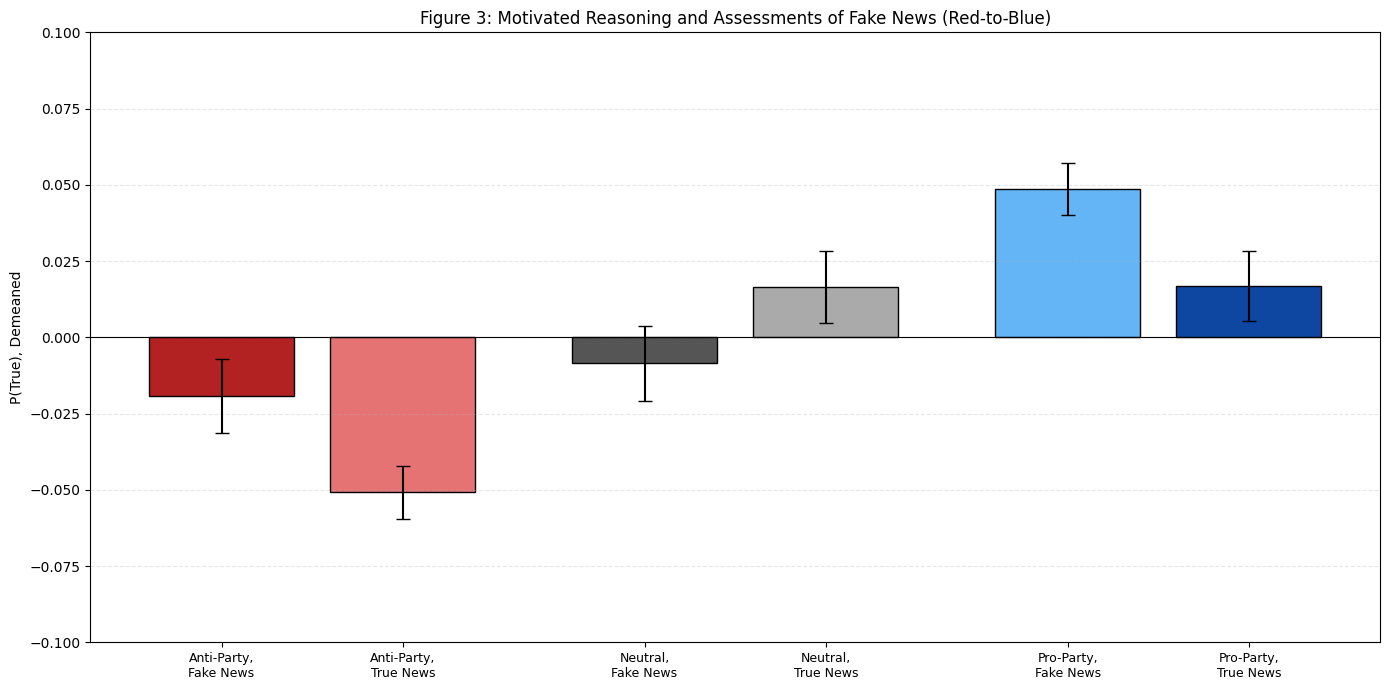

In [ ]:
# Visualization - claude help
plt.figure(figsize=(14, 7), facecolor='white')

# Palette colors: Deep Red -> Light Red -> Dark Gray -> Light Gray -> Light Blue -> Deep Blue
colors = ['#B22222', '#E57373', '#555555', '#AAAAAA', '#64B5F6', '#0D47A1']

labels = [
    "Anti-Party,\nFake News", "Anti-Party,\nTrue News",
    "Neutral,\nFake News", "Neutral,\nTrue News",
    "Pro-Party,\nFake News", "Pro-Party,\nTrue News"
]

plt.bar(stats_df['plot_axis'], stats_df['mean'], yerr=stats_df['ci_yerr'],
        capsize=5, color=colors, edgecolor='black', width=0.6)

plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(stats_df['plot_axis'], labels, fontsize=9)
plt.ylim(-0.1, 0.1)
plt.ylabel("P(True), Demeaned")
plt.title("Figure 3: Motivated Reasoning and Assessments of Fake News (Red-to-Blue)")
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### Replicate table 2: Motivated Reasoning and Perceived Truthfulness of News

This cell runs six different regression models using `pyfixest` to replicate Table 2, analyzing the impact of pro-party news, partisanship, anti-party news, and true news on perceived truthfulness (`prob_true`). It includes various fixed effects and controls, clustering standard errors at the subject level.

In [ ]:
# Prepare the variables as specified in the Stata code
df['anti_party_drop'] = df['anti_party']
controls = ['white', 'black', 'asian', 'latino', 'age', 'male', 'edu',
            'red_state', 'religious_group', 'log_inc']

In [ ]:
def coef_se(model, var):
    try:
        c = model.coef()[var]
        s = model.se()[var]
        return f"{c:.3f}", f"({s:.3f})"
    except (KeyError, AttributeError):
        return "", ""

# filters (mirror the Stata `if` conditions)
mask_pol   = (df['pro_party'] + df['anti_party']) == 1               # politicized only
mask_neut4 = (
    (df['net_party'] != 0) &
    ((df['politicized_news'] + df['neutral_news']) == 1) &
    ((df['message_greater'] + df['message_less']) == 1)
)

# anti_party_drop: used in spec4 to flag neutral-news inclusion in sample
df['anti_party_drop'] = df['anti_party']

controls = ("white + black + asian + latino + age + male + "
            "edu + red_state + religious_group + log_inc")

# run the 6 specs
with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    # Spec 1: demographic controls, Question + Round FE, NO Subject FE
    m1 = pf.feols(
        f"prob_true ~ pro_party + net_party + {controls} | round_number + topic_id",
        data=df[mask_pol], vcov={'CRV1': 'code'}
    )

    # Spec 2: Subject FE (main spec)
    m2 = pf.feols(
        "prob_true ~ pro_party | round_number + topic_id + code",
        data=df[mask_pol], vcov={'CRV1': 'code'}
    )

    # Spec 3: Partisanship x Pro-Party interaction
    m3 = pf.feols(
        "prob_true ~ pro_party + pro_party_str | round_number + topic_id + code",
        data=df[mask_pol], vcov={'CRV1': 'code'}
    )

    # Spec 4: include neutral news (no Question FE, reference category = neutral)
    m4 = pf.feols(
        "prob_true ~ pro_party + anti_party + anti_party_drop | round_number + code",
        data=df[mask_neut4], vcov={'CRV1': 'code'}
    )

    # Spec 5: True News effect
    m5 = pf.feols(
        "prob_true ~ true_news | round_number + topic_id + code",
        data=df[mask_pol], vcov={'CRV1': 'code'}
    )

    # Spec 6: Pro-Party + True News together
    m6 = pf.feols(
        "prob_true ~ pro_party + true_news | round_number + topic_id + code",
        data=df[mask_pol], vcov={'CRV1': 'code'}
    )

models = [m1, m2, m3, m4, m5, m6]
masks  = [mask_pol, mask_pol, mask_pol, mask_neut4, mask_pol, mask_pol]


# Final Display logic for Table 2

In [ ]:
# assemble display table
col_headers = [f"({i+1})" for i in range(6)]

variables = [
    ('Pro-Party News',          'pro_party'),
    ('Partisanship × Pro-Party','pro_party_str'),
    ('Anti-Party News',         'anti_party'),
    ('True News',               'true_news'),
]

fe_rows = {
    'Question FE':      ['Yes','Yes','Yes','No', 'Yes','Yes'],
    'Round FE':         ['Yes','Yes','Yes','Yes','Yes','Yes'],
    'Subject FE':       ['No', 'Yes','Yes','Yes','Yes','Yes'],
    'Subject controls': ['Yes','No', 'No', 'No', 'No', 'No'],
    'Neutral news':     ['No', 'No', 'No', 'Yes','No', 'No'],
}

obs_row  = [str(m._N) for m in models]
r2_row   = [f"{m._r2:.2f}" for m in models]
mean_row = [f"{df.loc[msk, 'prob_true'].mean():.3f}"
            for m, msk in zip(models, masks)]

# render as styled pandas DataFrame
idx, data = [], []

for label, var in variables:
    coef_row = [coef_se(m, var)[0] for m in models]
    se_row   = [coef_se(m, var)[1] for m in models]
    idx.append(label)
    data.append(coef_row)
    idx.append('')           # blank row for SE
    data.append(se_row)

idx.append(' ')
data.append(['']*6)

for fe_label, fe_vals in fe_rows.items():
    idx.append(fe_label)
    data.append(fe_vals)

idx.append('Observations')
data.append(obs_row)
idx.append('R²')
data.append(r2_row)
idx.append('Mean')
data.append(mean_row)

table2 = pd.DataFrame(data, index=idx, columns=col_headers)

print("Table 2 — Motivated Reasoning and Perceived Truthfulness of News")
print("=" * 80)
print("Note: OLS, errors clustered at subject level.\n"
      "Neutral news (col 4): Pro-Party/Anti-Party compared to neutral topics.\n"
      "Partisanship = |Rep rating − Dem rating|.\n")
display(table2)

Table 2 — Motivated Reasoning and Perceived Truthfulness of News
Note: OLS, errors clustered at subject level.
Neutral news (col 4): Pro-Party/Anti-Party compared to neutral topics.
Partisanship = |Rep rating − Dem rating|.



,(1),(2),(3),(4),(5),(6)
Pro-Party News,0.122,,0.115,0.018,,0.021
,(0.019),,(0.020),(0.017),,(0.018)
Partisanship × Pro-Party,,,,,,
,,,,,,
Anti-Party News,,,,,,
,,,,,,
True News,,,,,,
,,,,,,
,,,,,,
Question FE,Yes,Yes,Yes,No,Yes,Yes


### Replicate Figure 4: Motivated Reasoning by Topic

Data prep: this cell filters the DataFrame for subjects with a party preference (`net_party != 0`) and prepares it for fixed-effects regression. It sets up a multi-index for `PanelOLS` to apply Round, Topic, and Subject fixed effects.

In [ ]:
# Filtering for party preference
fig4_df = df[df['net_party'] != 0].copy()

# Mapping topic dummy variable names to their descriptive labels
topic_labels = {
    'good_topic1': 'Pro-Party x Climate',
    'good_topic7': 'Pro-Party x Mobility',
    'good_topic5': 'Pro-Party x Race',
    'good_topic2': 'Pro-Party x Refugees',
    'good_topic3': 'Pro-Party x Obama crime',
    'good_topic6': 'Pro-Party x Gender',
    'good_topic4': 'Pro-Party x Gun laws',
    'good_topic8': 'Pro-Party x Media',
    'good_topic1415': 'Pro-Party x Party score',
    'good_topic13': 'Pro-Performance'
}

# Define the specific order used in the original paper's figure.
ordered_cols = ['good_topic1', 'good_topic7', 'good_topic5', 'good_topic2',
                'good_topic3', 'good_topic6', 'good_topic4', 'good_topic8',
                'good_topic1415', 'good_topic13']

In [ ]:
# Setting multi-index to replicate Round, Topic, and Subject fixed effects.
reg_data = fig4_df.set_index(['code', 'round_number'])

# Dependent variable: P(True) assessment.
y = reg_data['prob_true']

# Independent variables: Interactions of good news and topic dummies.
X = reg_data[ordered_cols]

# Replicating original model: absorb(round_number topic_id code) cluster(code).
model = PanelOLS(y, X, entity_effects=True, time_effects=True)
results = model.fit(cov_type='clustered', cluster_entity=True)

/usr/local/lib/python3.12/dist-packages/linearmodels/panel/model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)


### Plot Figure 4

This cell defines a function to plot the coefficients and confidence intervals from the `PanelOLS` regression. It then calls this function to generate Figure 4, which visually represents the effect of pro-party/performance news on perceived truthfulness across different topics.

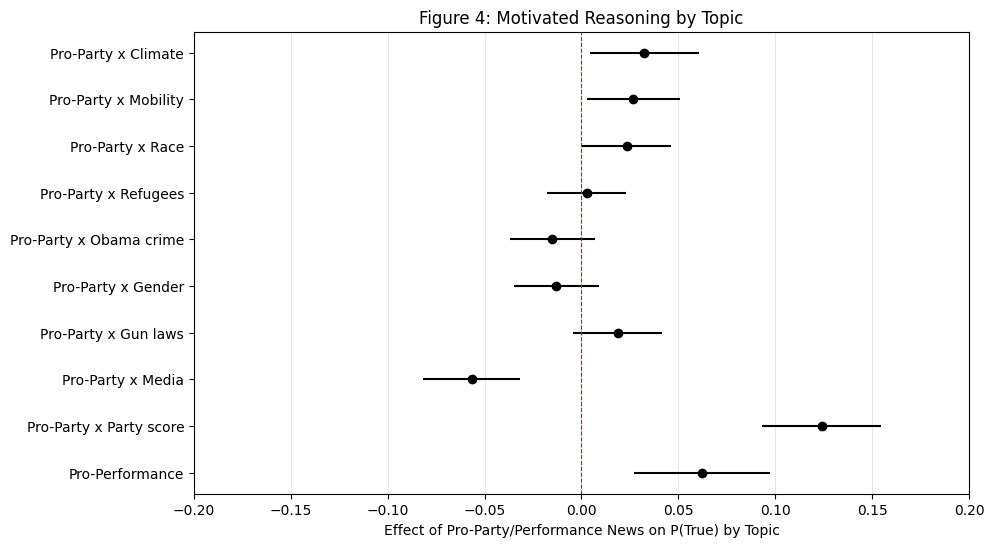

In [ ]:
# Generate the coefficient plot for fig 4
def plot_figure_4(params, conf_int, labels):
    plt.figure(figsize=(10, 6), facecolor='white')

    # Calculate error lengths for symmetric confidence intervals.
    errors = [params - conf_int.iloc[:, 0], conf_int.iloc[:, 1] - params]

    plt.errorbar(params, range(len(params)), xerr=errors, fmt='o', color='black', capsize=0)
    plt.yticks(range(len(params)), [labels[c] for c in ordered_cols])
    plt.axvline(0, color='red', linestyle='--', linewidth=0.8)

    plt.xlabel("Effect of Pro-Party/Performance News on P(True) by Topic")
    plt.title("Figure 4: Motivated Reasoning by Topic")
    plt.xlim(-0.2, 0.2)
    plt.gca().invert_yaxis()  # Match original descending order
    plt.grid(axis='x', alpha=0.3)
    plt.show()

# Extract results and execute plotting function.
plot_figure_4(results.params, results.conf_int(), topic_labels)

### Replicate Table 3: Motivated Reasoning and Following the Message Sent

This cell replicates Table 3 from the paper, which examines how motivated reasoning influences subjects' tendency to change their initial assessments in the direction of a provided message. It runs various `pyfixest` regression models using the `change_guess_message` as the dependent variable, incorporating fixed effects for round, topic, and subject, with clustered standard errors.

In [ ]:
mask_t3 = (
    df['change_guess_message'].notna() &
    ((df['pro_party'] + df['anti_party']) == 1)
)
d3 = df[mask_t3].copy()

with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    m1 = pf.feols("change_guess_message ~ pro_party | round_number + topic_id + code",
                  data=d3, vcov={"CRV1": "code"})

    m2 = pf.feols("change_guess_message ~ polarizing | round_number + topic_id + code",
                  data=d3, vcov={"CRV1": "code"})

    m3 = pf.feols("change_guess_message ~ pro_party + polarizing | round_number + topic_id + code",
                  data=d3, vcov={"CRV1": "code"})

    m4 = pf.feols("change_guess_message ~ pro_party + prob_true | round_number + topic_id + code",
                  data=d3, vcov={"CRV1": "code"})

    m5 = pf.feols("change_guess_message ~ polarizing + prob_true | round_number + topic_id + code",
                  data=d3, vcov={"CRV1": "code"})

    m6 = pf.feols("change_guess_message ~ pro_party + polarizing + prob_true | round_number + topic_id + code",
                  data=d3, vcov={"CRV1": "code"})

models = [m1, m2, m3, m4, m5, m6]



# Display table 3

Final logic to display table 3 w/ the help of claude

In [ ]:
# assemble table
variables = [
    ("Pro-Party News", "pro_party"),
    ("Polarizing News", "polarizing"),
    ("Pr(True)",        "prob_true"),
]

col_headers = [f"({i+1})" for i in range(6)]
idx, data = [], []

for label, var in variables:
    idx.append(label);  data.append([coef_se(m, var)[0] for m in models])
    idx.append("");     data.append([coef_se(m, var)[1] for m in models])

idx.append(" "); data.append([""]*6)

for fe_label, fe_vals in {
    "Question FE": ["Yes"]*6,
    "Round FE":    ["Yes"]*6,
    "Subject FE":  ["Yes"]*6,
}.items():
    idx.append(fe_label); data.append(fe_vals)

idx.append("Observations"); data.append([str(m._N) for m in models])
idx.append("R²");           data.append([f"{m._r2:.2f}" for m in models])
idx.append("Mean");         data.append([f"{d3['change_guess_message'].mean():.3f}"]*6)

table3 = pd.DataFrame(data, index=idx, columns=col_headers)

print("Table 3 — Motivated Reasoning and Following the Message Sent")
print("=" * 75)
print("OLS, errors clustered at subject level.")
print("Second-guess group only. Only Pro-Party/Anti-Party news observations.")
print("Polarizing news = message says answer is farther from population mean.\n")
display(table3)

Table 3 — Motivated Reasoning and Following the Message Sent
OLS, errors clustered at subject level.
Second-guess group only. Only Pro-Party/Anti-Party news observations.
Polarizing news = message says answer is farther from population mean.



,(1),(2),(3),(4),(5),(6)
Pro-Party News,0.122,,0.115,0.018,,0.021
,(0.019),,(0.020),(0.017),,(0.018)
Polarizing News,,0.060,0.034,,-0.008,-0.013
,,(0.018),(0.018),,(0.016),(0.016)
Pr(True),,,,1.126,1.136,1.128
,,,,(0.059),(0.058),(0.059)
,,,,,,
Question FE,Yes,Yes,Yes,Yes,Yes,Yes
Round FE,Yes,Yes,Yes,Yes,Yes,Yes
Subject FE,Yes,Yes,Yes,Yes,Yes,Yes


### Replicate Figure 5: Heterogeneity in Partisan Direction

This cell prepares the data and runs a high-dimensional fixed-effects regression using `AbsorbingLS` to analyze how the effect of Republican/Democratic news on perceived truthfulness varies across different demographic groups.

In [ ]:
df_fig5 = df.copy()

# This creates integer representations of the IDs (0, 1, 2...)
df_fig5['code_id'] = pd.factorize(df_fig5['code'])[0]
df_fig5['topic_id_num'] = pd.factorize(df_fig5['topic_id'])[0]
df_fig5['round_num'] = pd.factorize(df_fig5['round_number'])[0]

# Generate demographic dummies
df_fig5['older'] = (df_fig5['age'] > 32).astype(int)
df_fig5['college'] = (df_fig5['edu'] > 13).astype(int)
df_fig5['richer'] = (df_fig5['inc'] >= 50000).astype(int)

# Ensure 'rep_news' and other dummies are strictly numeric
for col in ['rep_news', 'pro_rep', 'male', 'white', 'red_state', 'religious_group']:
    df_fig5[col] = pd.to_numeric(df_fig5[col], errors='coerce').fillna(0).astype(int)

# Create interaction terms
demos = ['pro_rep', 'older', 'male', 'white', 'college', 'richer', 'red_state', 'religious_group']
interaction_cols = []
for demo in demos:
    col_name = f'rep_x_{demo}'
    df_fig5[col_name] = df_fig5['rep_news'] * df_fig5[demo]
    interaction_cols.append(col_name)

# Filter
mask = (df_fig5['pro_party'] + df_fig5['anti_party'] == 1)
df_filtered = df_fig5[mask].dropna(subset=['prob_true', 'rep_news'] + interaction_cols)

# High-Dimensional Fixed Effects Regression
exog_vars = interaction_cols + ['rep_news']
model = AbsorbingLS(
    dependent=df_filtered['prob_true'].astype(float),
    exog=df_filtered[exog_vars].astype(float),
    absorb=df_filtered[['topic_id_num', 'round_num', 'code_id']]
)

# Cluster by the original 'code_id'
results = model.fit(cov_type='clustered', clusters=df_filtered['code_id'])



# Plot Figure 5
plotting logic for the interaction coefficients with their confidence intervals to create Figure 5.

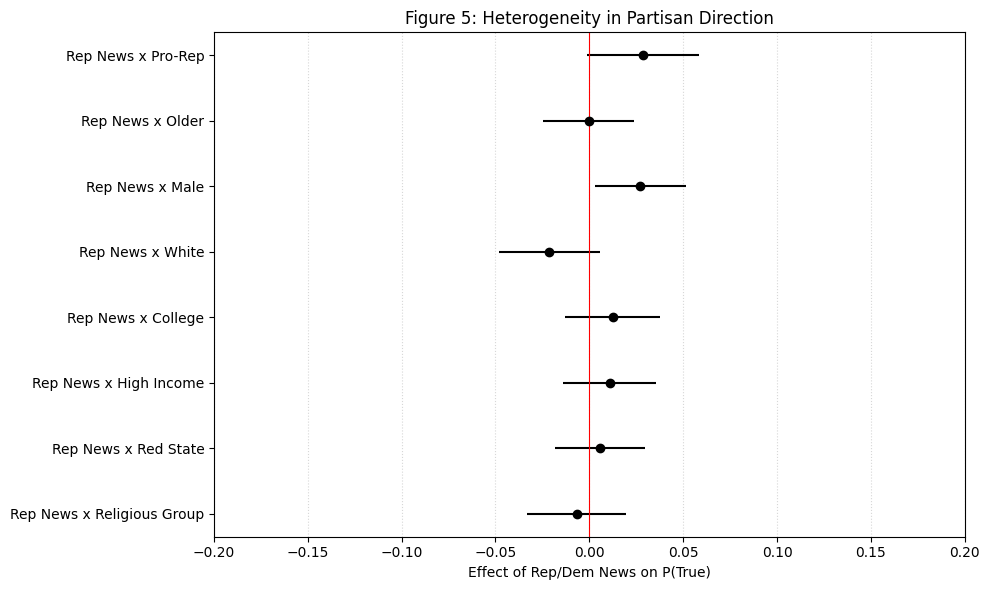

In [ ]:
# Create Figure 5 Plot
coefs = results.params[interaction_cols]
errors = results.std_errors[interaction_cols]

labels = [
    "Rep News x Pro-Rep", "Rep News x Older", "Rep News x Male",
    "Rep News x White", "Rep News x College", "Rep News x High Income",
    "Rep News x Red State", "Rep News x Religious Group"
]

plt.figure(figsize=(10, 6), facecolor='white')
plt.errorbar(coefs, range(len(coefs)), xerr=1.96*errors, fmt='o', color='black', capsize=0)
plt.yticks(range(len(coefs)), labels)
plt.axvline(0, color='red', linewidth=0.8)
plt.xlabel("Effect of Rep/Dem News on P(True)")
plt.xlim(-0.2, 0.2)
plt.xticks(np.arange(-0.2, 0.25, 0.05))
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle=':', alpha=0.5)
plt.title("Figure 5: Heterogeneity in Partisan Direction")
plt.tight_layout()
plt.show()

# Figure 6 / 7: Appendix Figures Below

We're not sure if we're including these yet

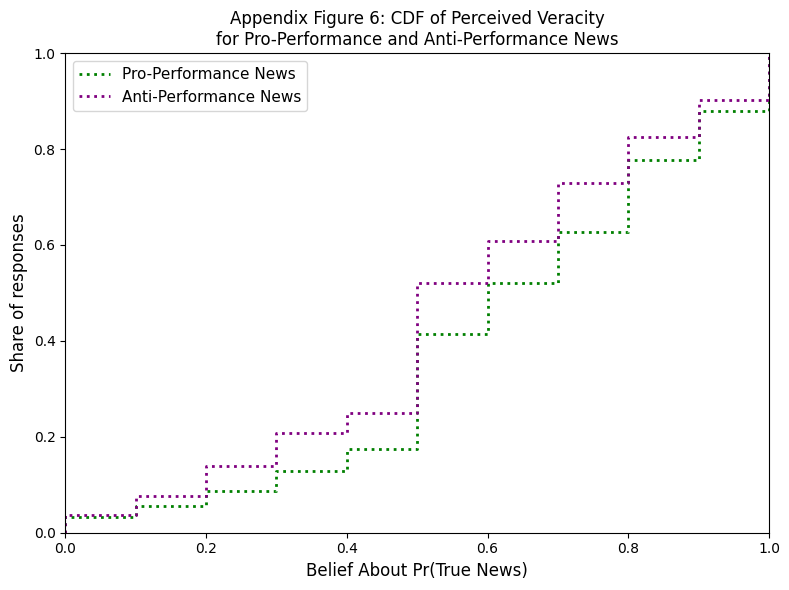

Pro-performance n  = 490
Anti-performance n = 490


In [ ]:
# Filter: performance topic only (topic_id == 13), must have received a message
fig6_data = df[
    ((df['good_news'] == 1) | (df['bad_news'] == 1)) &
    (df['topic_id'] == 13)
].copy()

pro_perf  = fig6_data[fig6_data['good_news'] == 1]['prob_true'].sort_values()
anti_perf = fig6_data[fig6_data['bad_news']  == 1]['prob_true'].sort_values()

def cdf_xy(series):
    """Return (x, y) arrays for an empirical CDF."""
    x = np.concatenate([[series.iloc[0]], series.values])
    y = np.linspace(0, 1, len(x))
    return x, y

fig, ax = plt.subplots(figsize=(8, 6), facecolor='white')

x_pro,  y_pro  = cdf_xy(pro_perf)
x_anti, y_anti = cdf_xy(anti_perf)

ax.step(x_pro,  y_pro,  where='post', color='green',  linestyle='dotted',
        linewidth=2, label='Pro-Performance News')
ax.step(x_anti, y_anti, where='post', color='purple', linestyle='dotted',
        linewidth=2, label='Anti-Performance News')

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("Belief About Pr(True News)", fontsize=12)
ax.set_ylabel("Share of responses", fontsize=12)
ax.set_title("Appendix Figure 6: CDF of Perceived Veracity\nfor Pro-Performance and Anti-Performance News",
             fontsize=12)
ax.legend(fontsize=11)
ax.set_facecolor('white')
plt.tight_layout()
plt.show()

print(f"Pro-performance n  = {len(pro_perf)}")
print(f"Anti-performance n = {len(anti_perf)}")


## Replicating Appendix Figure 7 ##

This is a CDF of the probability a subject will claim a news story is true ($P(\text{True})$). This figure is meant to support Hypothesis 2 by showing that subjects are generally 'Bayesian', or rational int he sense that they generally find true news to be more likely true than fake news. The "True News" curve in the graph (red)consistently sits to the right of the "Fake News" curve (blue). As the paper mentions, the Fake News distribution first-order stochastically dominates the True News distribution. This means that for fake news, a higher cumulative share of responses are at lower probability scores, meaning that more subjects are able to successfully distinguish true news.

In [ ]:
# filter out neutral news
df_fig7 = df[(df['good_news'] == 1) | (df['bad_news'] == 1)].copy()

# Ensure prob_true is numeric
df_fig7['prob_true'] = pd.to_numeric(df_fig7['prob_true'], errors='coerce')
df_fig7 = df_fig7.dropna(subset=['prob_true', 'true_news'])

###

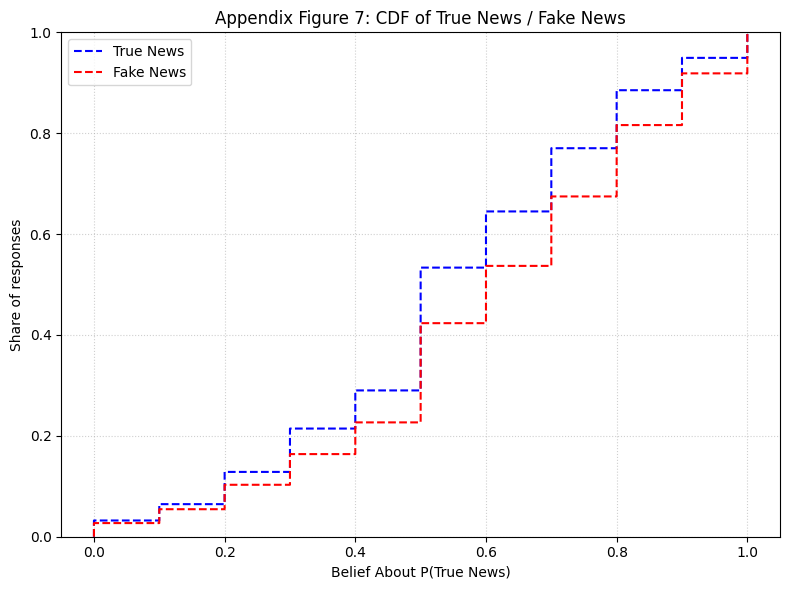

In [ ]:
# Plot CDF as an sns ecdfplot (equivalent of cdfplot in Stata)
plt.figure(figsize=(8, 6), facecolor='white')

sns.ecdfplot(
    data=df_fig7,
    x='prob_true',
    hue='true_news',
    palette={0: 'red', 1: 'blue'},
    linestyle='--'
)

# Formatting to match the paper
plt.legend(title=None, labels=['True News', 'Fake News']) # Order matches hue 1, 0
plt.xlabel("Belief About P(True News)")
plt.ylabel("Share of responses")
plt.title("Appendix Figure 7: CDF of True News / Fake News")
plt.grid(axis='both', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()